# Luca Rotundo
## Progetto corso "Data Manipulation and Visualization"
- - -

# Traccia:

## In questo dataset trovi la distribuzione settimanale delle impression acquisite attraverso diversi canali di marketing da parte di un’azienda di esempio.

Il dato di "Sales" rappresenta le vendite generate con quella distribuzione di impression.

### Come primo lavoro ti viene chiesto di individuare i canali dove le impression sono più efficaci nel generare vendite, per poter ottimizzare gli investimenti. 

Decidi di iniziare a tracciare la distribuzione delle impression sui 7 canali e di analizzare anche una metrica di andamento globale, quindi nel dataset troverai queste 8 colonne:

- Facebook
- Google Search Impressions
- Email Impressions
- YouTube (Paid & Organic)
- Affiliate Channel
- Views
- Overall Views
- Sales

Immagina ora di voler collaborare con una no profit impegnata nella distribuzione di reportage indipendenti e di dover proporre una strategia di marketing.

Potresti provare a capire quali sono i canali dove le impression convertono meglio in vendite, se ci sono trend di stagionalità, se ci sono outlier e se c’è correlazione tra le variabili.

Un possibile output del tuo lavoro potrebbe essere la proposta di una strategia di marketing-mix e di investimento in ads per il prossimo anno per la no profit con cui vuoi collaborare. Ma prima assicurati di aver esplorato i dati a fondo e di mostrare i tuoi ragionamenti.

## L’analisi è stata impostata in ottica esplorativa, con l’obiettivo di individuare pattern, associazioni e possibili indicazioni strategiche senza assumere relazioni causali definitive.

### Import librerie e DataFrame

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
#Import del dataset

df = pd.read_csv("Sample Media Spend Data.csv")

df

,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,1/6/2018,392,422,408,3.498950e+05,73580,12072,682,59417
1,A,1/13/2018,787,904,110,5.062702e+05,11804,9499,853,56806
2,A,1/20/2018,81,970,742,4.300422e+05,52232,17048,759,48715
3,A,1/27/2018,25,575,65,4.177457e+05,78640,10207,942,72047
4,A,2/3/2018,565,284,295,4.085058e+05,40561,5834,658,56235
...,...,...,...,...,...,...,...,...,...,...
3046,Z,2/1/2020,29239,25311,622406,1.459071e+06,45026,12098,53667,82707
3047,Z,2/8/2020,26230,28031,624409,5.342505e+05,227070,9548,53665,84503
3048,Z,2/15/2020,24749,31281,439362,4.227182e+05,393685,9861,55561,147325
3049,Z,2/22/2020,20713,30356,464178,6.085799e+05,424676,10221,49221,111525


In [3]:
#Describe per capire la distribuzione del DataFrame

df.describe()

,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
count,3051.000000,3051.000000,3.051000e+03,3.051000e+03,3.051000e+03,3051.000000,3051.000000,3.051000e+03
mean,15093.941658,13355.673222,8.861738e+05,7.605094e+05,2.691269e+05,22910.902655,27980.914127,1.859014e+05
std,30785.884979,24079.399689,1.355076e+06,6.260141e+05,4.665117e+05,21617.637497,52054.976687,2.322079e+05
min,1.000000,1.000000,7.000000e+00,4.089445e+04,2.900000e+01,910.000000,2.000000,1.543600e+04
25%,537.000000,712.500000,1.698280e+05,3.784969e+05,5.707350e+04,9127.000000,747.000000,7.339350e+04
50%,2699.000000,4110.000000,4.905310e+05,5.909708e+05,1.275230e+05,16658.000000,7879.000000,1.135730e+05
75%,17358.000000,16230.500000,1.022622e+06,9.622466e+05,2.835050e+05,27486.500000,34111.500000,2.029755e+05
max,518190.000000,270453.000000,1.715044e+07,7.317730e+06,7.558435e+06,175791.000000,635057.000000,3.575430e+06


In [4]:
#Shape per capire la dimensione del DataFrame

print(df.shape,"\n")

#Info per avere informazioni generiche sul DataFrame

print(df.info(),"\n")

#Conversione Calendar_Week in datetime

df['Calendar_Week'] = pd.to_datetime(df['Calendar_Week'])

df.info()

(3051, 10) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3051 entries, 0 to 3050
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Division               3051 non-null   object 
 1   Calendar_Week          3051 non-null   object 
 2   Paid_Views             3051 non-null   int64  
 3   Organic_Views          3051 non-null   int64  
 4   Google_Impressions     3051 non-null   int64  
 5   Email_Impressions      3051 non-null   float64
 6   Facebook_Impressions   3051 non-null   int64  
 7   Affiliate_Impressions  3051 non-null   int64  
 8   Overall_Views          3051 non-null   int64  
 9   Sales                  3051 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 238.5+ KB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3051 entries, 0 to 3050
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------        

In [5]:
#Rename per cambiare nomi alle colonne

df = df.rename(columns={"Paid_Views":"Youtube_Paid_Views","Organic_Views":"Youtube_Organic_Views"})

In [6]:
#Controllo per vedere se sono presenti valori null del DataFrame

df.isna().sum()

Division                 0
Calendar_Week            0
Youtube_Paid_Views       0
Youtube_Organic_Views    0
Google_Impressions       0
Email_Impressions        0
Facebook_Impressions     0
Affiliate_Impressions    0
Overall_Views            0
Sales                    0
dtype: int64

In [7]:
#Controllo per vedere se sono presenti valori duplicati

df.loc[df.duplicated()]

,Division,Calendar_Week,Youtube_Paid_Views,Youtube_Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales


### Analisi delle Feature

In [8]:
#Value_counts per contare se le divisioni hanno tutte lo stesso valore

df["Division"].value_counts()

Division
Z    226
B    113
Y    113
X    113
W    113
V    113
U    113
T    113
S    113
R    113
Q    113
P    113
O    113
A    113
M    113
L    113
K    113
J    113
I    113
H    113
G    113
F    113
E    113
D    113
C    113
N    113
Name: count, dtype: int64

### Tutte le divisioni sembrano seguire la stessa cardinalità temporale, tranne Z, che rompe la regolarità del dataset.

In [9]:
#Ordino la divisione per "Calendar_Week", così da poter analizzare se i dati seguono un pattern o sono degli errori ripetuti

df[df["Division"] == "Z"].sort_values("Calendar_Week")


,Division,Calendar_Week,Youtube_Paid_Views,Youtube_Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
2825,Z,2018-01-06,165,346,440,9.393009e+05,156226,43811,223,113911
2938,Z,2018-01-06,887,376,940,5.126463e+05,89989,26445,317,60627
2826,Z,2018-01-13,101,571,347,1.358203e+06,24364,37350,611,107477
2939,Z,2018-01-13,286,296,111,7.407334e+05,15233,25077,298,78949
2827,Z,2018-01-20,873,128,716,1.152332e+06,81574,57746,344,115549
...,...,...,...,...,...,...,...,...,...,...
2935,Z,2020-02-15,45720,62301,873511,7.745703e+05,617157,20858,107629,249249
3049,Z,2020-02-22,20713,30356,464178,6.085799e+05,424676,10221,49221,111525
2936,Z,2020-02-22,36729,58704,892030,1.116236e+06,612204,26511,94376,203100
2937,Z,2020-02-29,29735,52409,831908,8.037641e+05,308350,21448,81611,182305


### Come si può vedere dai dati, sono presenti due osservazioni per la stessa settimana con valori divergenti.
### Dato che la divisione `Z` presenta un’anomalia strutturale, ho deciso di svolgere un’analisi principale senza `Z` e una seconda analisi con `Z` aggregata, usata come controllo di robustezza per verificare se questa anomalia alteri i risultati principali.

# Analisi senza divisione Z


## Scatter per capire se esistono differenze tra divisioni

In [10]:
df_senza_z = df[~(df["Division"] == "Z")].copy()

fig = px.scatter(df_senza_z,
                 x="Calendar_Week",
                 y="Sales",
                 color="Division",
                 hover_name="Division",
                 hover_data="Overall_Views",
                 size="Sales",
                 title="Distribuzione delle vendite nel tempo"
                )
fig.update_layout(height=720)
fig.show()

Come si può vedere dal grafico a dispersione, la `divisione B` sembra collocarsi su livelli di `Sales` generalmente elevati rispetto alle altre divisioni, mostra anche picchi elevati in determinati periodi, suggerendo una forte variabilità e possibili pattern ricorrenti.

In [11]:
#Tramite groupby prende la media delle sales per divisioni

print(round(df_senza_z.groupby("Division")["Sales"].mean().sort_values(ascending=False),4))

Division
B    876130.5841
E    457977.7345
O    360136.9912
V    311044.8319
L    253410.5487
N    239736.4248
S    227507.6106
D    201645.4425
G    196175.7699
Q    153390.4602
P    129760.4159
K    120983.8053
I    119505.4602
F    114471.8673
W    111215.1593
M    104951.1593
A    103391.2389
X     95836.7611
U     94428.7522
H     92296.4956
J     88443.4867
C     81640.0088
R     78423.3274
Y     69235.0354
T     38331.8142
Name: Sales, dtype: float64


### Isolo la `divisione B` dato che è una divisione dominante.
Come si può notare, la dispersione delle Sales nella `divisione B` è elevata, coerentemente con i picchi osservati nel grafico temporale.

Nella `divisione B` la **media** delle `Sales` è sensibilmente superiore alla **mediana**, suggerendo una distribuzione **asimmetrica a destra**, con pochi valori molto elevati che trascinano verso l’alto il valore medio.

In [12]:
df_B = df_senza_z[df_senza_z["Division"] == "B"]

media_sales_B = df_B["Sales"].mean()
print(f"La media delle Sales per la divisione B é: {round(media_sales_B,4)} €.\n")

mediana_sales_B = df_B["Sales"].median()

print(f"La mediana delle Sales per la divisione B é: {round(mediana_sales_B,4)}.\n")

varianza_sales_B = df_B["Sales"].var()

print(f"La varianza delle Sales per la divisione B é: {round(varianza_sales_B,4)}.\n")

df_B.describe()

La media delle Sales per la divisione B é: 876130.5841 €.

La mediana delle Sales per la divisione B é: 665200.0.

La varianza delle Sales per la divisione B é: 339122530016.4058.



,Calendar_Week,Youtube_Paid_Views,Youtube_Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
count,113,113.000000,113.000000,1.130000e+02,1.130000e+02,1.130000e+02,113.000000,113.000000,1.130000e+02
mean,2019-02-02 00:00:00,66616.884956,57691.955752,4.058473e+06,2.855814e+06,1.270666e+06,75675.265487,123854.690265,8.761306e+05
min,2018-01-06 00:00:00,13.000000,5.000000,7.000000e+00,1.399749e+06,4.160000e+02,39128.000000,20.000000,3.952040e+05
25%,2018-07-21 00:00:00,552.000000,714.000000,2.614655e+06,2.333309e+06,5.412990e+05,62676.000000,688.000000,5.859250e+05
50%,2019-02-02 00:00:00,41457.000000,21987.000000,3.581869e+06,2.727133e+06,8.870370e+05,72644.000000,71520.000000,6.652000e+05
75%,2019-08-17 00:00:00,116191.000000,100749.000000,4.680448e+06,3.134953e+06,1.647626e+06,88308.000000,195104.000000,9.163250e+05
max,2020-02-29 00:00:00,518190.000000,270453.000000,1.715044e+07,7.317730e+06,7.558435e+06,121571.000000,635057.000000,3.575430e+06
std,NaN,87404.333808,67809.891302,3.225463e+06,8.484756e+05,1.286902e+06,18414.906900,144693.772897,5.823423e+05


### Istogramma rappresentante la distribuzione delle vendite nella `divisione B`.
La distribuzione delle `Sales` nella `divisione B` non appare simmetrica: sono presenti valori elevati che estendono la coda a destra, coerentemente con la differenza tra media e mediana.

In [13]:
fig = px.histogram(df_B,x="Sales",
                   nbins=30,
                   marginal="box",
                   color_discrete_sequence=px.colors.qualitative.Prism,
                   title="Distribuzione delle vendite nella Divisione B")

fig.update_layout(height=600)

fig.show()

### Grafico che mostra la distribuzione delle vendite nelle `divisioni`.
Alcune divisioni mostrano distribuzioni più concentrate, altre una maggiore dispersione e code più marcate.

In [14]:
fig = px.histogram(df_senza_z,
                   x="Sales",
                   nbins=30,
                   color="Division",
                   facet_col="Division",
                   facet_col_wrap=4,
                   title="Distribuzione delle vendite per Divisione")

fig.update_layout(height=3000)

# Assicura che tutti gli assi X siano visibili
fig.for_each_xaxis(lambda x: x.update(showticklabels=True))

fig.show()

## Perché la divisione B presenta livelli di Sales più elevati rispetto alle altre divisioni?


## Grafico che mostra tutte le metriche per divisione

In [15]:
df_senza_z

paid = df_senza_z.groupby("Division")["Youtube_Paid_Views"].mean()

organic = df_senza_z.groupby("Division")["Youtube_Organic_Views"].mean()

google = df_senza_z.groupby("Division")["Google_Impressions"].mean()

email = df_senza_z.groupby("Division")["Email_Impressions"].mean()

facebook = df_senza_z.groupby("Division")["Facebook_Impressions"].mean()

affiliate = df_senza_z.groupby("Division")["Affiliate_Impressions"].mean()

overall = df_senza_z.groupby("Division")["Overall_Views"].mean()

sales_media = df_senza_z.groupby("Division")["Sales"].mean()

sales_somma = df_senza_z.groupby("Division")["Sales"].sum()


fig = make_subplots(rows=6, cols=2,subplot_titles=[
    "Youtube Paid Views - media",
    "Youtube Organic Views - media",
    "Google Impressions - media",
    "Email Impressions - media",
    "Facebook Impressions - media",
    "Affiliate Impressions - media",
    "Overall Views - media",
    "Sales - media",
    "Sales - somma totale",],specs=[
    [{},{}],[{},{}],[{},{}],[{"colspan":2},None],[{"colspan":2},None],[{"colspan":2},None]
])


#Youtube_Paid_Views

fig.add_trace(go.Bar(x=paid.index,
                     y=paid.values,
                     name="Youtube_Paid_Views",
                     marker=dict(color=paid.values,colorscale="oryel"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=1,col=1)

#Youtube_Organic_Views

fig.add_trace(go.Bar(x=organic.index,
                     y=organic.values,
                     name="Youtube_Organic_Views",
                     marker=dict(color=organic.values,colorscale="sunsetdark"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=1,col=2)

#Google_Impressions

fig.add_trace(go.Bar(x=google.index,
                     y=google.values,
                     name="Google_Impressions",
                     marker=dict(color=google.values,colorscale="magenta"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=2,col=1)

#Email_Impressions

fig.add_trace(go.Bar(x=email.index,
                     y=email.values,
                     name="Email_Impressions",
                     marker=dict(color=email.values,colorscale="purp"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=2,col=2)

#Facebook_Impressions

fig.add_trace(go.Bar(x=facebook.index,
                     y=facebook.values,
                     name="Facebook_Impressions",
                     marker=dict(color=facebook.values,colorscale="teal"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=3,col=1)

#Affiliate_Impressions

fig.add_trace(go.Bar(x=affiliate.index,
                     y=affiliate.values,
                     name="Affiliate_Impressions",
                     marker=dict(color=affiliate.values,colorscale="darkmint"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=3,col=2)

#Overall_Views

fig.add_trace(go.Bar(x=overall.index,
                     y=overall.values,
                     name="Overall_Views",
                     marker=dict(color=overall.values,colorscale="plotly3_r"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=4,col=1)

#Sales_Media

fig.add_trace(go.Bar(x=sales_media.index,
                     y=sales_media.values,
                     name="Sales_Media",
                     marker=dict(color=sales_media.values,colorscale="brwnyl"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=5,col=1)

#Sales_Somma

fig.add_trace(go.Bar(x=sales_somma.index,
                     y=sales_somma.values,
                     name="Sales_Somma",
                     marker=dict(color=sales_somma.values,colorscale="gray_r"),
                     hovertemplate="<b>Division:</b> %{x}<br><b>Valore:</b> %{y}<extra></extra>"),row=6,col=1)

fig.update_layout(title="Dashboard KPI Canali Marketing & Sales",height=2000,width=1070)

fig.update_xaxes(title="Divisioni",row=1,col=1)
fig.update_yaxes(title="Valore",row=1,col=1)


fig.update_xaxes(title="Divisioni",row=1,col=2)


fig.update_xaxes(title="Divisioni",row=2,col=1)
fig.update_yaxes(title="Valore",row=2,col=1)

fig.update_xaxes(title="Divisioni",row=2,col=2)


fig.update_xaxes(title="Divisioni",row=3,col=1)
fig.update_yaxes(title="Valore",row=3,col=1)

fig.update_xaxes(title="Divisioni",row=3,col=2)


fig.update_xaxes(title="Divisioni",row=4,col=1)
fig.update_yaxes(title="Valore",row=4,col=1)


fig.update_xaxes(title="Divisioni",row=5,col=1)
fig.update_yaxes(title="Valore",row=5,col=1)


fig.update_xaxes(title="Divisioni",row=6,col=1)
fig.update_yaxes(title="Valore",row=6,col=1)

fig.show()

Come si vede dal grafico la `Divisione B` ha una presenza maggiore in quasi tutte le metriche.  

La `Divisione B` presenta livelli medi elevati in molte metriche di traffico e anche nelle Sales, ma questo non basta da solo a stabilire che il maggiore traffico sia la causa principale delle vendite più alte.


`Google Impressions` e `Email Impressions` generano volumi enormi rispetto:
- `Affiliate Impressions (molto basso)`
- `Facebook impressions (medio-basso)` 

Questo suggerisce che i canali `search` e `CRM` abbiano un peso quantitativo più rilevante nel dataset rispetto ai canali `social` o `affiliate`, ma non consente da solo di stabilirne il ruolo causale nelle vendite.

La `Divisione V` mostra livelli relativamente elevati in `Youtube Paid`, `Youtube Organic` e `Overall_Views`, risultando interessante come caso da monitorare.

## Relplot per visualizzare le sales nelle divisioni

Il grafico mostra un aumento ricorrente delle `Sales` tra `Ottobre` e `Dicembre` in molte divisioni. Il pattern è compatibile con una componente di fine anno, ma non consente di distinguere tra stagionalità della domanda e intensificazione delle attività promozionali.

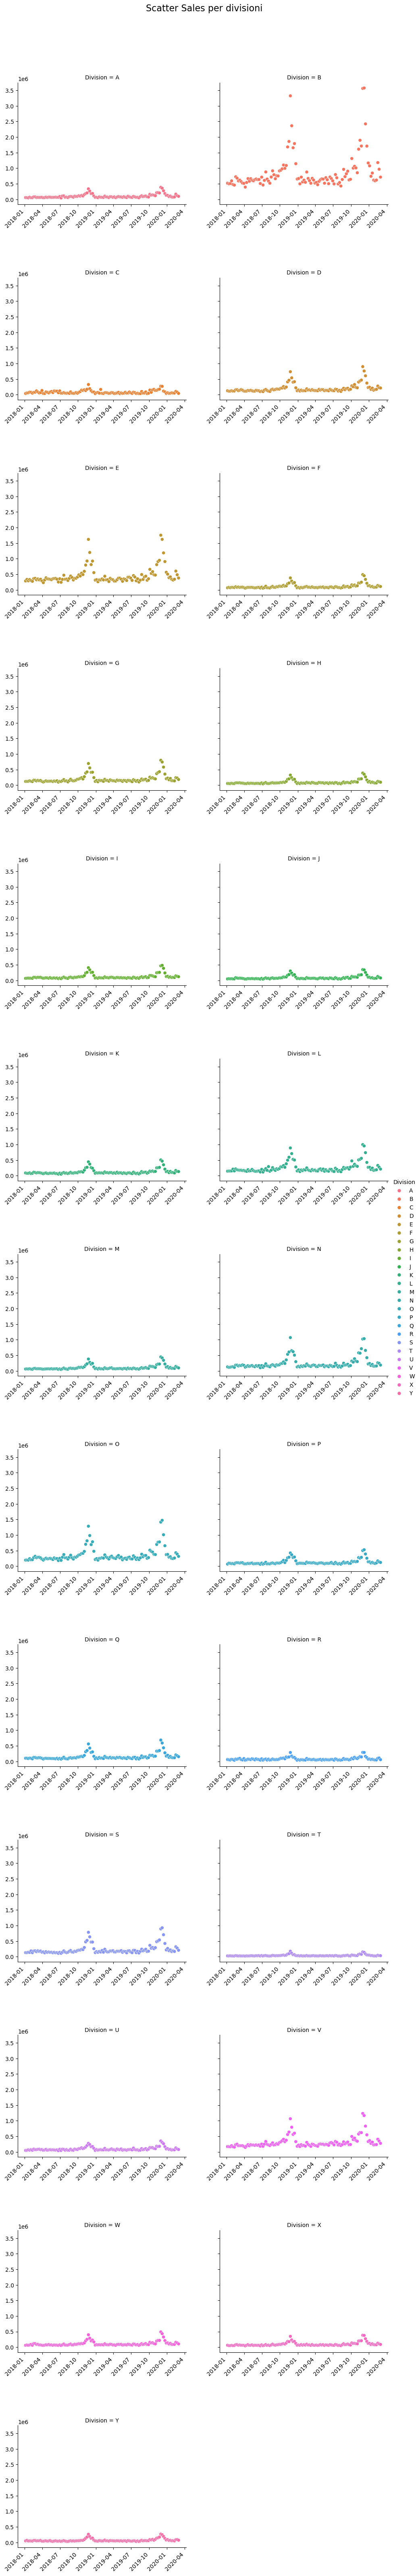

In [16]:
g = sns.relplot(data=df_senza_z,x="Calendar_Week",y="Sales",hue="Division",col="Division",col_wrap=2,)

# Assicura che tutti gli assi X siano visibili
g.tick_params(axis='x', labelbottom=True)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

g.set_axis_labels("", "")
g.figure.subplots_adjust(hspace=0.6, wspace=0.2, top=0.95)
g.figure.suptitle("Scatter Sales per divisioni", fontsize=16)

plt.show()

## Grafico per confrontare l'andamento delle Overall Views nel tempo

La `divisione B` mostra livelli elevati di  `Overall_Views` rispetto alle altre divisioni, ma i picchi temporali non coincidono perfettamente con quelli delle Sales.

Questo suggerisce che la visibilità complessiva non si traduca in modo lineare o immediato in vendite.



In [17]:
fig = px.line(df_senza_z,
              x="Calendar_Week",
              y="Overall_Views",
              color="Division",
              hover_name="Division",
              title="Overall_Views nel tempo")
fig.update_layout(height=700)
fig.show()

## Grafico per verificare la distribuzione delle sales nelle divisioni

Come si evince dal grafico molte `divisioni` presentano maggiore `dispersione` e `outlier` marcati.  
Questo ci fa intuire che la `distribuzione dei dati` è asimmetrica a `destra` con la `coda più lunga` verso i valori alti, mentre la maggior parte dei dati si concentra a sinistra.

Gli outlier presenti nelle divisioni risultano coerenti con i picchi temporali osservati nei mesi di fine anno.

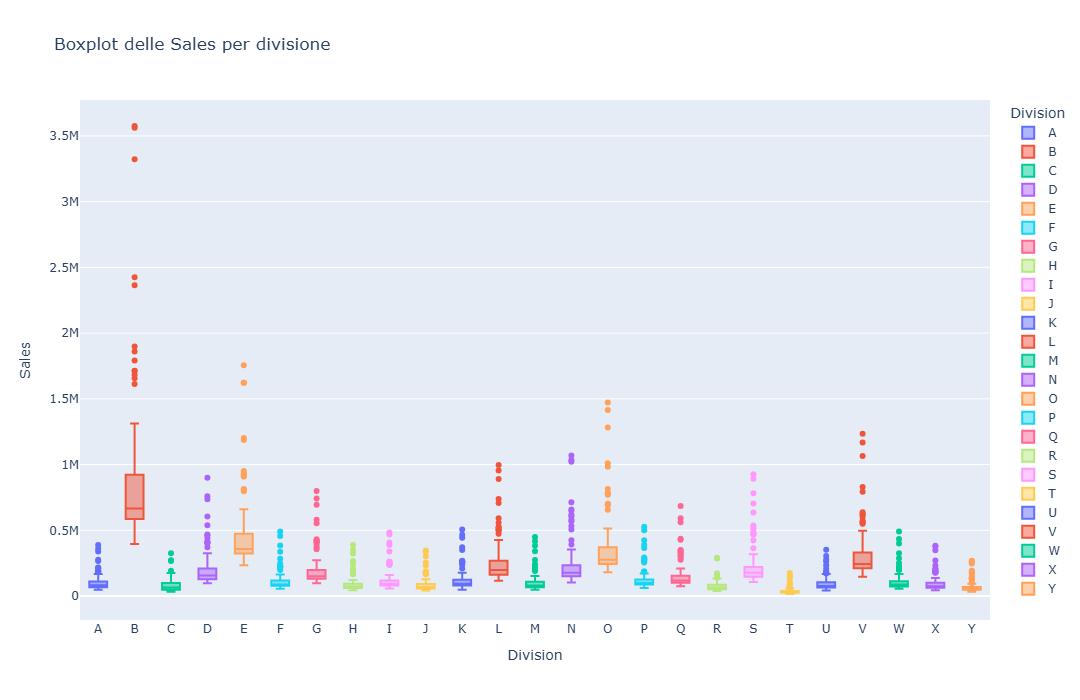

In [28]:
fig = px.box(df_senza_z,
             x="Division",
             y="Sales",
             color="Division",
             hover_name="Division",
             hover_data=["Calendar_Week"],
             title="Boxplot delle Sales per divisione")
fig.update_layout(height=700)
fig.show()

### Grafico che mostra le varie metriche nel periodo Ottobre-Dicembre negli anni disponibili
Nel periodo `Ottobre-Dicembre`, queste tre metriche non mostrano un pattern temporale chiaramente sovrapponibile a quello delle `Sales`.


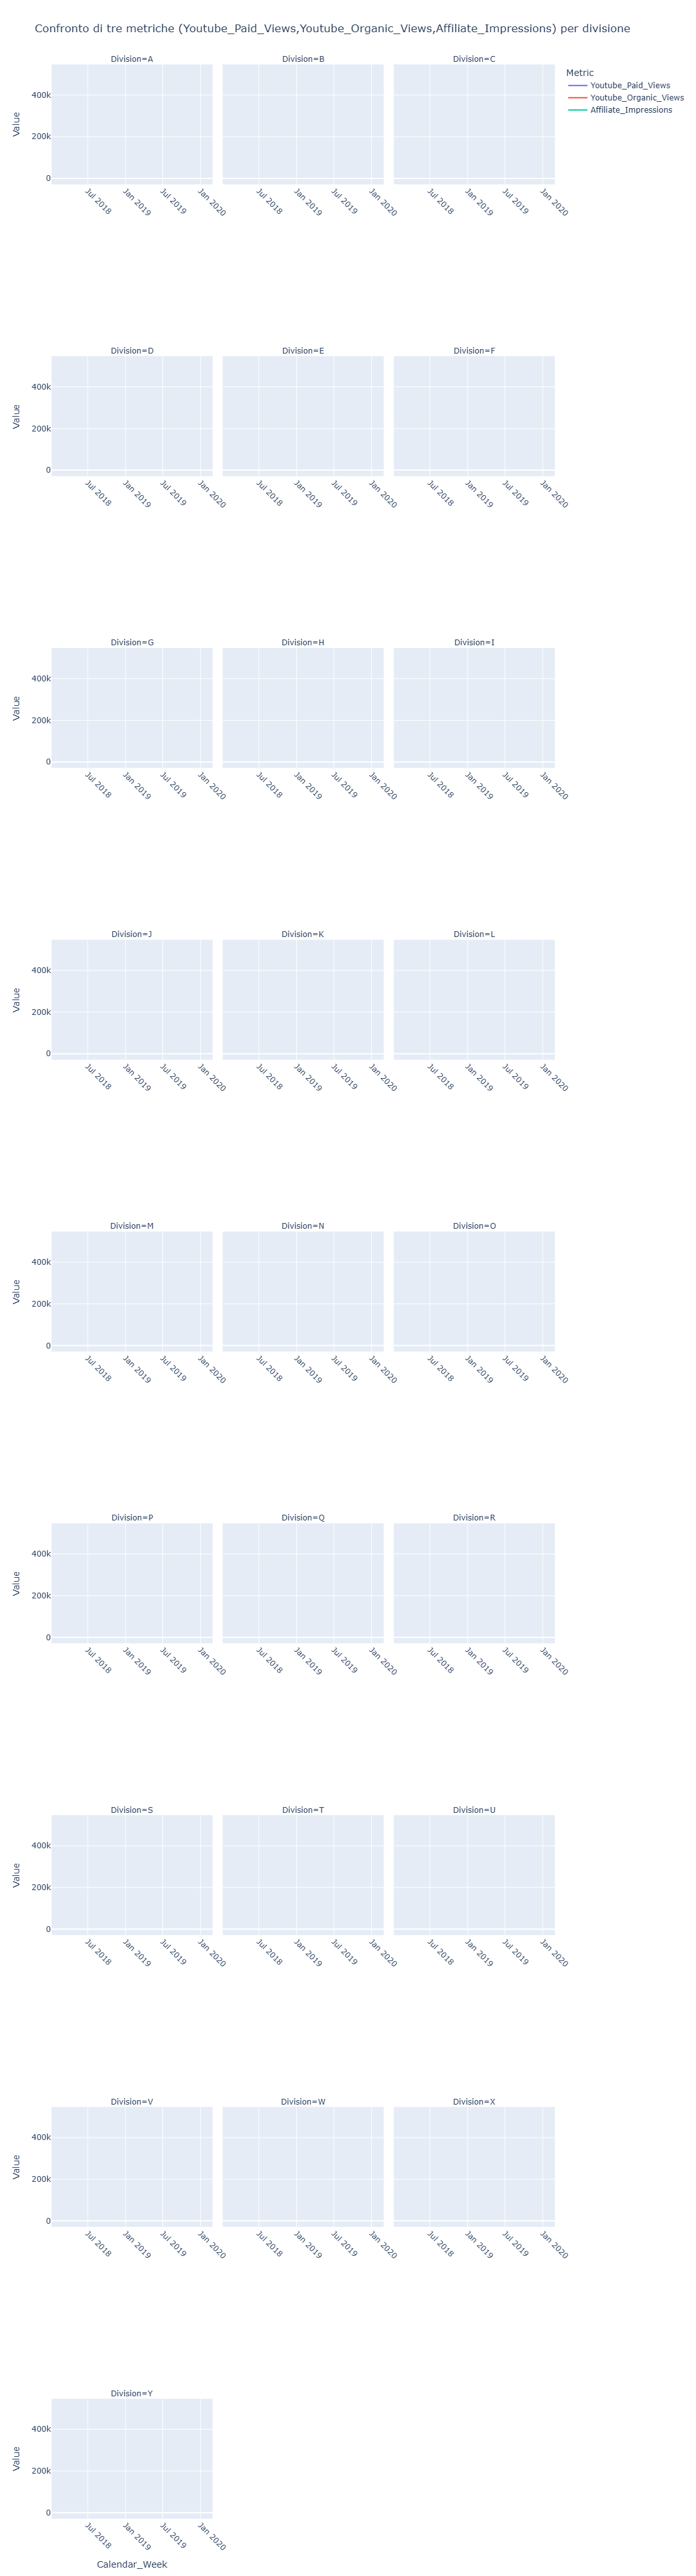

In [27]:
df_metriche = df_senza_z.melt(
    id_vars=["Calendar_Week", "Division"],
    value_vars=["Youtube_Paid_Views", "Youtube_Organic_Views", "Affiliate_Impressions"],
    var_name="Metric",
    value_name="Value"
)

fig = px.line(
    df_metriche,
    x="Calendar_Week",
    y="Value",
    color="Metric",
    hover_name="Metric",
    facet_col="Division",
    facet_col_wrap=3,
    title="Confronto di tre metriche (Youtube_Paid_Views,Youtube_Organic_Views,Affiliate_Impressions) per divisione"
)

fig.update_layout(height=4000)

# Ruota le date su tutti i subplot
fig.update_xaxes(tickangle=45)

# Assicura che tutti gli assi X siano visibili
fig.for_each_xaxis(lambda x: x.update(showticklabels=True))

fig.show()

### Grafico confronto metriche impressions nel periodo Ottobre-Dicembre negli anni disponibili


Si osserva una relazione positiva tra `Google Impressions` e `Sales` in molte divisioni nei periodi di maggiore attività, ma non è chiaro se sia dovuta a un effetto diretto o a dinamiche comuni come trend temporali o dinamiche promozionali.

La metrica `Google Impressions` mostra livelli più elevati rispetto alle altre metriche in molte divisioni.

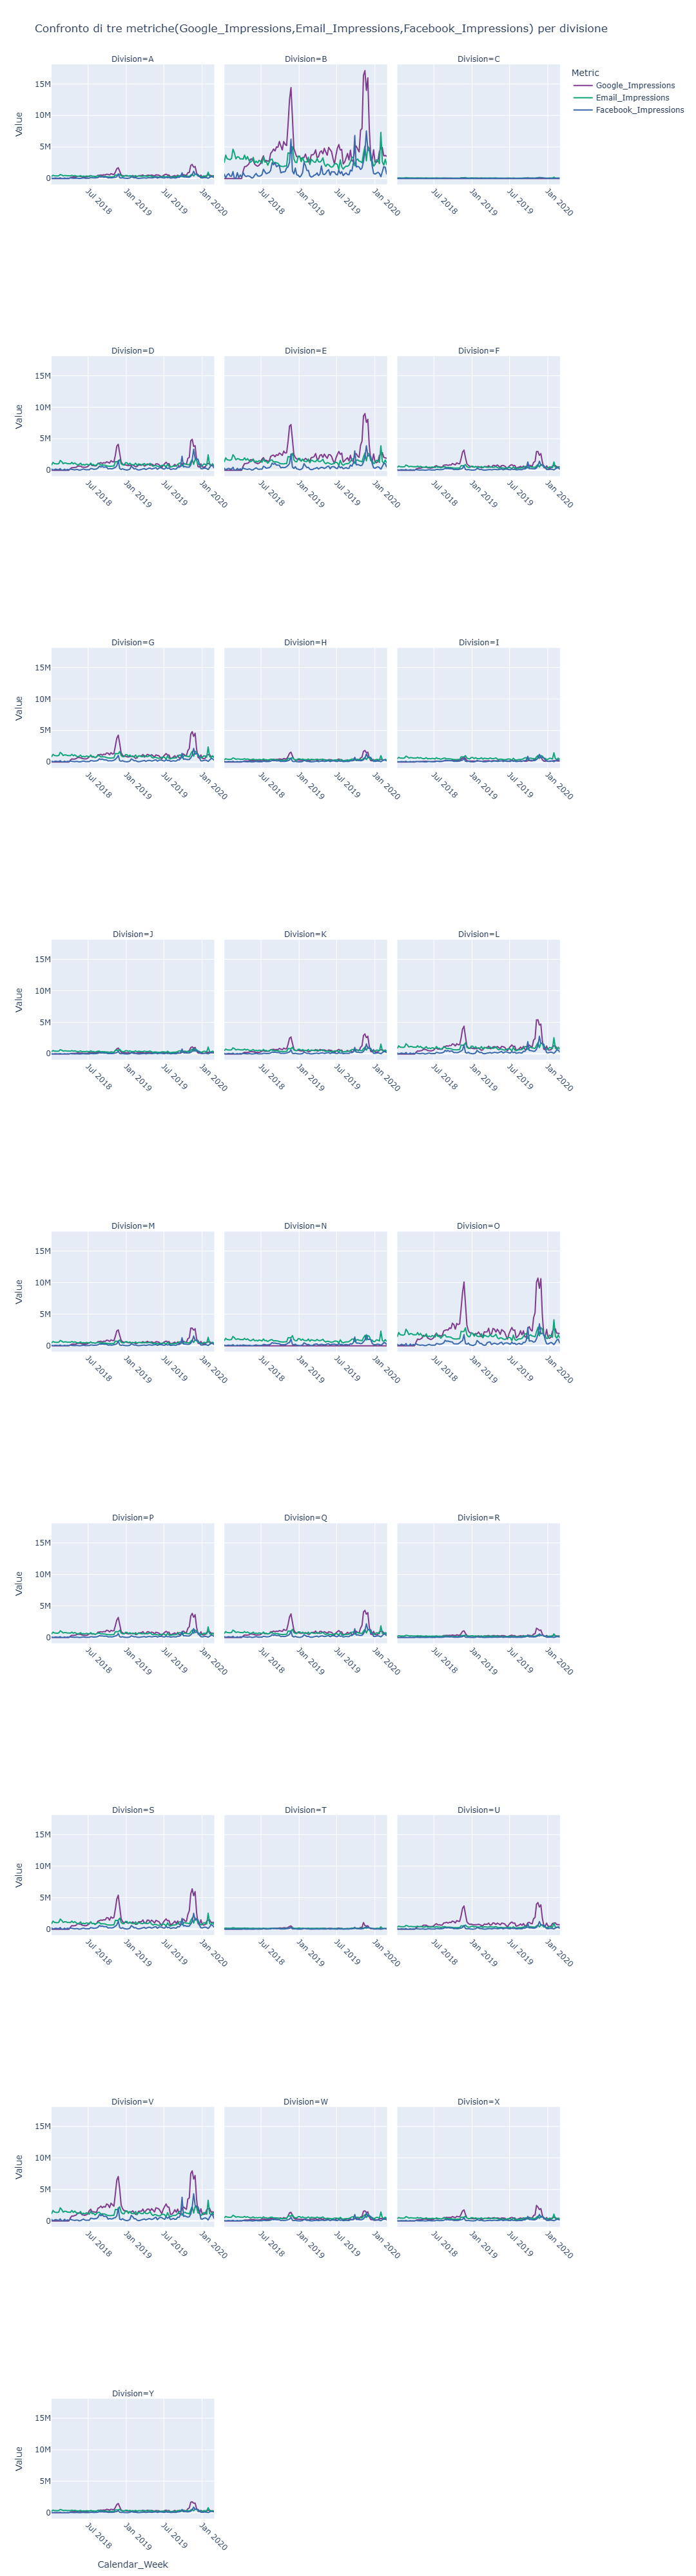

In [26]:
df_metriche2 = df_senza_z.melt(
    id_vars=["Calendar_Week", "Division"],
    value_vars=["Google_Impressions","Email_Impressions","Facebook_Impressions"],
    var_name="Metric",
    value_name="Value"
)

fig = px.line(df_metriche2,
              x="Calendar_Week",
              y="Value",
              color="Metric",
              color_discrete_sequence=px.colors.qualitative.Bold,
              hover_name="Metric",
              facet_col="Division",
              facet_col_wrap=3,
              title="Confronto di tre metriche(Google_Impressions,Email_Impressions,Facebook_Impressions) per divisione")

fig.update_layout(height=4000)

# Ruota le date su tutti i subplot
fig.update_xaxes(tickangle=45)

# Assicura che tutti gli assi X siano visibili
fig.for_each_xaxis(lambda x: x.update(showticklabels=True))


fig.show()

### Grafico confronto Google Impressions, Facebook Impressions e Sales
Il grafico mostra una crescita di fine anno sia in `Google Impressions` sia in `Facebook Impressions`, in corrispondenza dei periodi di maggiore attività delle `Sales`.

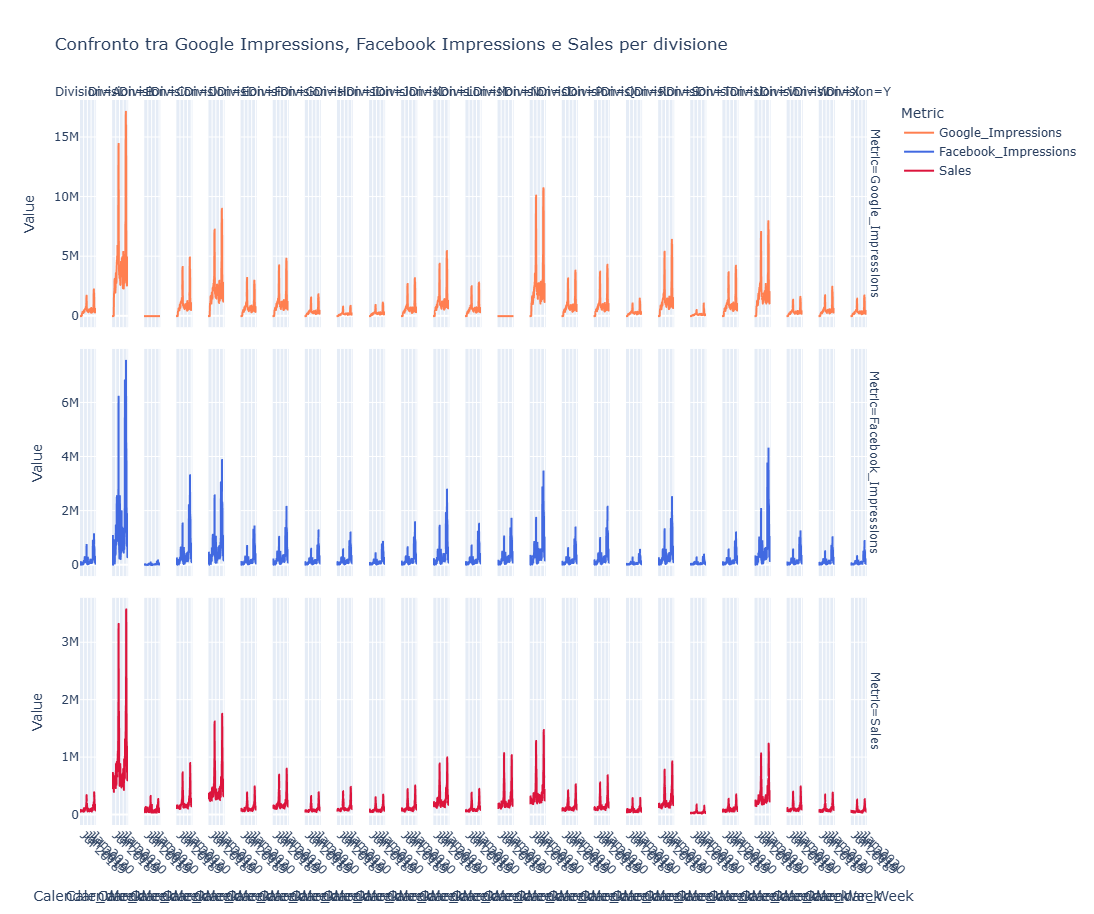

In [29]:
df_comparison = df_senza_z.copy()

df_comparison = df_comparison.melt(
    id_vars=["Calendar_Week", "Division"],
    value_vars=["Google_Impressions","Facebook_Impressions", "Sales"],
    var_name="Metric",
    value_name="Value"
)

fig = px.line(
    df_comparison,
    x="Calendar_Week",
    y="Value",
    color="Metric",
    color_discrete_map={"Google_Impressions":"coral","Facebook_Impressions":"royalblue","Sales":"crimson"},
    hover_name="Metric",
    facet_col="Division",
    facet_row="Metric",
    title="Confronto tra Google Impressions, Facebook Impressions e Sales per divisione"
)

fig.update_xaxes(tickangle=45)
fig.update_layout(height=900, width=4000)

# numero divisioni = numero colonne
n_col = df_comparison["Division"].nunique()

# numero metriche = numero righe
metrics = df_comparison["Metric"].unique()
n_metrics = len(metrics)

# Per condividere la scala Y solo all'interno della stessa riga
for row_idx in range(n_metrics):

    base_axis_index = row_idx * n_col + 1
    base_axis_ref = "y" if base_axis_index == 1 else f"y{base_axis_index}"

    for col_idx in range(n_col):
        axis_index = row_idx * n_col + col_idx + 1
        axis_name = "yaxis" if axis_index == 1 else f"yaxis{axis_index}"
        fig.layout[axis_name].matches = base_axis_ref

fig.show()

# Analisi con divisione Z aggregata

Dato che non posso identificare quale osservazione rappresenti meglio la divisione-settimana, uso la media per non eliminare informazione né raddoppiare artificialmente il peso di `Z`.


In [22]:
#Prendo i valori di z, li raggruppo e ne calcolo la media per ottenere la Z aggregata.
df_z_agg = df[df["Division"] == "Z"].groupby("Calendar_Week", as_index=False).mean(numeric_only=True)

#associo la colonna Division
df_z_agg["Division"] = "Z"

#concateno df_z_agg e df_senza_z per ottenere df_z aggregato
df_z = pd.concat([df_senza_z,df_z_agg],ignore_index=True)

df_z

,Division,Calendar_Week,Youtube_Paid_Views,Youtube_Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,2018-01-06,392.0,422.0,408.0,3.498950e+05,73580.0,12072.0,682.0,59417.0
1,A,2018-01-13,787.0,904.0,110.0,5.062702e+05,11804.0,9499.0,853.0,56806.0
2,A,2018-01-20,81.0,970.0,742.0,4.300422e+05,52232.0,17048.0,759.0,48715.0
3,A,2018-01-27,25.0,575.0,65.0,4.177457e+05,78640.0,10207.0,942.0,72047.0
4,A,2018-02-03,565.0,284.0,295.0,4.085058e+05,40561.0,5834.0,658.0,56235.0
...,...,...,...,...,...,...,...,...,...,...
2933,Z,2020-02-01,40859.5,38816.0,904111.5,2.067245e+06,58318.0,16121.5,78877.5,113750.5
2934,Z,2020-02-08,37301.0,41277.5,941720.0,7.568157e+05,284246.5,14151.5,77842.5,113226.5
2935,Z,2020-02-15,35234.5,46791.0,656436.5,5.986443e+05,505421.0,15359.5,81595.0,198287.0
2936,Z,2020-02-22,28721.0,44530.0,678104.0,8.624079e+05,518440.0,18366.0,71798.5,157312.5


In [23]:
fig = px.scatter(df_z,
                 x="Calendar_Week",
                 y="Sales",
                 size="Sales",
                 color="Division",
                 hover_name="Division",
                 title="Distribuzione delle vendite nel tempo (Z aggregata)")

fig.update_layout(height=720)
fig.show()

In [24]:
fig = px.histogram(
    df_z[df_z["Division"].isin(["Z", "B"])],
    x="Sales",
    hover_name="Division",
    nbins=30,
    marginal="box",
    color="Division",
    barmode="overlay",
    color_discrete_sequence=px.colors.qualitative.Dark24,
    title="Distribuzione vendite B vs Z"
)

fig.update_layout(height=620)
fig.show()

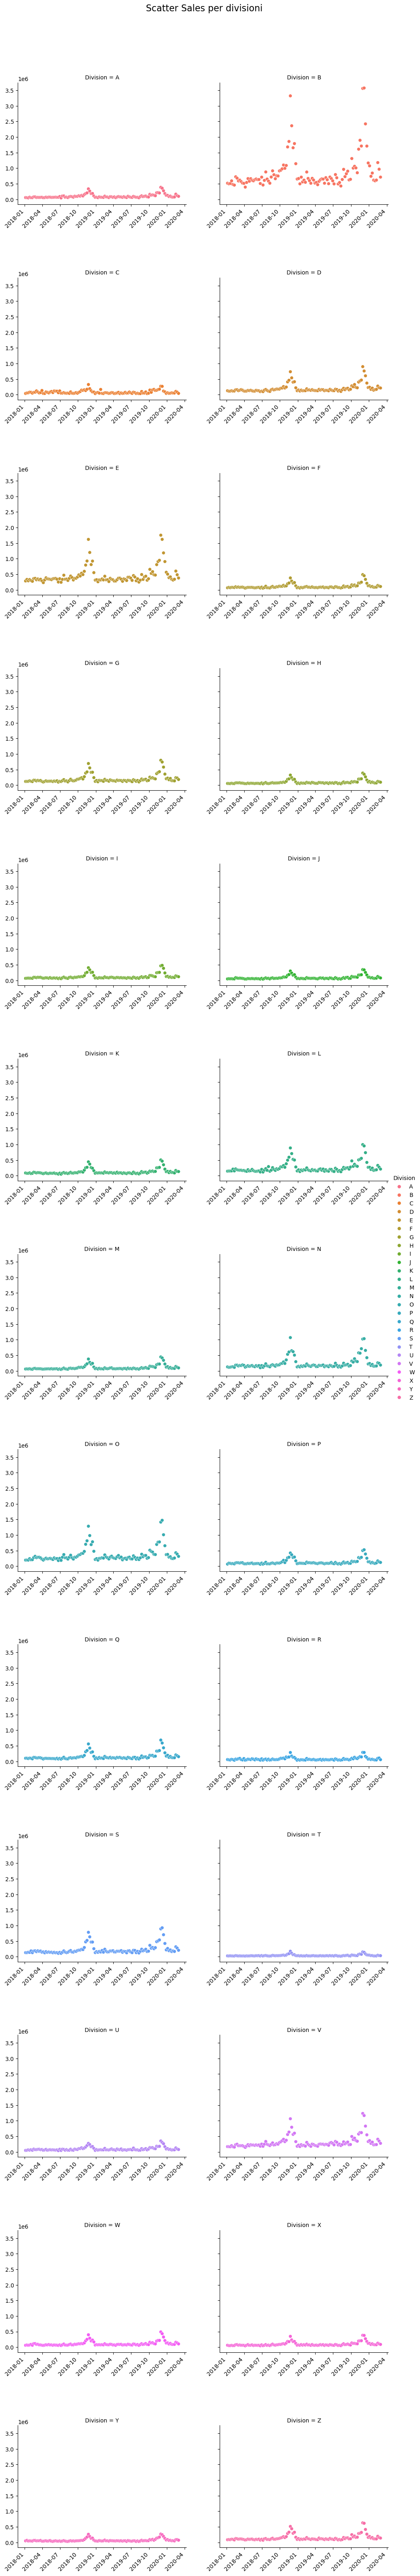

In [25]:
g = sns.relplot(data=df_z,x="Calendar_Week",y="Sales",hue="Division",col="Division",col_wrap=2,)

# Assicura che tutti gli assi X siano visibili
g.tick_params(axis='x', labelbottom=True)

for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

g.set_axis_labels("", "")
g.figure.subplots_adjust(hspace=0.6, wspace=0.2, top=0.95)
g.figure.suptitle("Scatter Sales per divisioni", fontsize=16)

plt.show()

## Come possiamo vedere dai grafici la presenza o meno della divisione Z non altera in maniera evidente le principali evidenze descrittive emerse.
La presenza della `divisione Z`, una volta aggregata, non altera in modo evidente i principali pattern descrittivi osservati.  
La `divisione Z` mostra un andamento complessivamente coerente con quello delle altre divisioni, pur restando un caso particolare.

# Conclusioni

Dall'analisi sono emersi diversi insight utili per andare a strutturare una strategia di marketing-mix.

Prima di discutere gli insight principali, è opportuno ricordare che nel dataset è emerso un problema strutturale relativo alla divisione Z.  

Nella divisione Z sono stati localizzati due osservazioni per la stessa settimana con dati divergenti.  
Per ovviare a questa discrepanza, ho deciso di analizzare il dataset senza considerare la divisione Z e poi considerando la divisione Z in forma aggregata tramite media per verificare se questa anomalia strutturale influenzi o meno l'esito dell'analisi.


Uno dei primi insight emersi riguarda le differenze marcate tra divisioni.
L’analisi evidenzia differenze marcate tra le divisioni, in termini di:

- livello medio di Sales
- dispersione
- presenza di outlier
- intensità delle metriche di marketing

Un altro aspetto emerso dall'analisi è la presenza di un pattern ricorrente di fine anno.  
Tra novembre e dicembre si osserva un aumento ricorrente delle Sales e di alcune metriche marketing. il pattern è compatibile con una componente di fine anno, ma non consente di distinguere pienamente tra stagionalità della domanda e maggiore pressione promozionale.

Dall'analisi è risultato che Google emerge come il canale più coerentemente associato alle Sales, ma i picchi condivisi con Facebook suggeriscono una dinamica promozionale congiunta, soprattutto a fine anno.  
Questa evidenza suggerisce una possibile priorità strategica da coltivare, ma non dimostra causalmente una maggior conversione.

Questo suggerisce di considerare Google come priorità strategica, da affiancare però ad altri canali che mostrano pattern convergenti nei periodi chiave.

Un altro aspetto importante rilevato è che Overall Views e Sales non si muovono sempre in modo perfettamente allineato, suggerendo che una maggiore visibilità non si traduce necessariamente in un incremento immediato delle vendite.

La distribuzione delle Sales appare asimmetrica a destra, con pochi valori particolarmente elevati che influenzano la media e riflettono una dinamica non uniforme tra periodi e divisioni.  
Questo è coerente con la presenza di picchi di fine anno che incidono in modo rilevante sulla distribuzione complessiva delle vendite.



# Proposta strategia di marketing-mix

Alla luce dell’analisi svolta, una possibile strategia di **marketing-mix** per l’anno successivo potrebbe prevedere un presidio prioritario del canale **Google**, che nel dataset emerge come il canale più **coerentemente associato** alle vendite in diverse divisioni e in più periodi temporali. Questo suggerisce che Google possa rappresentare il **principale canale da monitorare** e ottimizzare in ottica di **conversione**.

Accanto a Google, anche **Facebook** merita attenzione strategica, poiché mostra picchi temporali simili a quelli delle vendite, soprattutto nei periodi di **fine anno**. Questo potrebbe indicare una **dinamica promozionale congiunta**, nella quale più canali contribuiscono contemporaneamente all’aumento delle Sales, rendendo opportuno un utilizzo integrato dei due strumenti piuttosto che una valutazione isolata.

L’analisi ha inoltre evidenziato un **pattern ricorrente** tra **novembre** e **dicembre**, con un aumento delle vendite e di alcune metriche marketing. Di conseguenza, una possibile indicazione operativa sarebbe quella di intensificare gli **investimenti pubblicitari** nei mesi di fine anno, periodo che appare particolarmente favorevole in termini di risposta del mercato, pur non potendo distinguere con certezza tra effetto stagionale della domanda e maggiore pressione promozionale.

Per quanto riguarda gli altri canali, come Email, Affiliate e YouTube Paid/Organic, il loro ruolo appare **meno chiaramente associato** alle vendite nel confronto diretto con Google e Facebook. Questo non implica necessariamente una loro inefficacia, ma suggerisce che possano avere una **funzione più di supporto**, **awareness** o accompagnamento lungo il funnel, piuttosto che di driver diretto delle **conversioni**.

Infine, poiché le **Overall Views** non risultano sempre perfettamente allineate alle vendite, la strategia non dovrebbe basarsi esclusivamente sull’aumento della visibilità complessiva, ma piuttosto sulla **capacità dei singoli canali** di accompagnare in modo più coerente i momenti di crescita delle **Sales**. In quest’ottica, la proposta più prudente è quella di orientare il **marketing-mix** verso un rafforzamento di **Google e Facebook nei periodi chiave**, mantenendo gli altri canali come supporto e prevedendo future analisi o test più mirati per validare con maggiore precisione l’efficacia relativa di ciascun canale.